In [288]:
import warnings
import os
import gc
import numpy as np
import absl.logging
import pandas as pd
import xgboost as xgb
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy import stats
from datetime import datetime
from keras.models import Sequential
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, SVMSMOTE, ADASYN
from sklearn.preprocessing import StandardScaler, LabelEncoder
from keras.layers import Dense, Dropout, BatchNormalization, Input
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, roc_curve, auc, accuracy_score, confusion_matrix

In [289]:
warnings.filterwarnings("ignore")

In [290]:
class TxnDataPreProcessor():

  # Transaction Data Preprocessor

  def __init__(self, dataSet):
    self.dataSet = dataSet

  def processMissingData(self):

    for col in self.dataSet.columns:
      if(col in self.dataSet.categoricalCols):
        self.dataSet.processedDataSet[col].fillna('UnKnown', inplace = True)
      elif(col in self.dataSet.numericalCols):
        self.dataSet.processedDataSet[col].fillna(self.dataSet.processedDataSet[col].median(), inplace = True)

  def processData(self, isTrain=True, labelEncoders=None):

    self.processMissingData()
    self.extractNewFeatures()

    categoricalData = self.dataSet.categoricalCols + ['HourBins', 'AgeGrp', 'TxnSize', 'DeviceLocation']

    if isTrain:
        labelEncoders = dict()
        for col in categoricalData:
            if col in self.dataSet.processedDataSet.columns:
                labelEncoders[col] = LabelEncoder()
                self.dataSet.processedDataSet[col] = labelEncoders[col].fit_transform(self.dataSet.processedDataSet[col])
        return [self.dataSet.processedDataSet, labelEncoders]
    else:
        for col in categoricalData:
            if col in self.dataSet.processedDataSet.columns and col in labelEncoders:
                self.dataSet.processedDataSet[col] = self.dataSet.processedDataSet[col].map(lambda x: 'Unknown' if x not in labelEncoders[col].classes_ else x)
                if 'Unknown' not in labelEncoders[col].classes_:
                    labelEncoders[col].classes_ = np.append(labelEncoders[col].classes_, 'Unknown')
                self.dataSet.processedDataSet[col] = labelEncoders[col].transform(self.dataSet.processedDataSet[col])
        return self.dataSet.processedDataSet

  def extractNewFeatures(self):

    dataSet = self.dataSet.processedDataSet
    dataSet['Weekend?'] = (pd.to_datetime(dataSet['Transaction Date']).dt.dayofweek >= 5).astype(int)
    dataSet['HourBins'] = pd.cut(dataSet['Transaction Hour'], bins=[-np.inf, 6, 12, 18, np.inf], labels=['Ngt', 'Mrng', 'Aft', 'Eve'])
    dataSet['WeekDay'] = pd.to_datetime(dataSet['Transaction Date']).dt.dayofweek

    dataSet['AmtLog'] = np.log1p(dataSet['Transaction Amount'])
    dataSet['AmtZS'] = stats.zscore(dataSet['Transaction Amount'], nan_policy='omit')
    dataSet['AmtPerQty'] = dataSet['Transaction Amount'] / (dataSet['Quantity'] + 1)

    dataSet['QtyLog'] = np.log1p(dataSet['Quantity'])
    dataSet['TxnSize'] = pd.qcut(dataSet['Transaction Amount'], q=5, labels=['VS', 'S', 'M', 'L', 'VL'], duplicates='drop')

    dataSet['NewAccnt?'] = (dataSet['Account Age Days'] <= 30).astype(int)
    dataSet['AgeGrp'] = pd.cut(dataSet['Customer Age'], bins=[0, 25, 35, 50, 65, np.inf], labels=['Young', 'YoungAdult', 'Adult', 'Senior', 'Elder'])
    dataSet['AccntAge'] = dataSet['Account Age Days'] // 7

    dataSet['HighQty'] = (dataSet['Quantity'] > dataSet['Quantity'].quantile(0.95)).astype(int)
    dataSet['UnusualTxnHrs'] = ((dataSet['Transaction Hour'] < 6) | (dataSet['Transaction Hour'] > 22)).astype(int)
    dataSet['HighAmt'] = (dataSet['Transaction Amount'] > dataSet['Transaction Amount'].quantile(0.95)).astype(int)

    dataSet['DeviceLocation'] = f"{dataSet['Customer Location']}_{dataSet['Device Used']}"


In [291]:
class TxnDataSet:

  # Transaction Dataset

  def __init__(self, dataSrcPath):
    self.dataSrcPath = dataSrcPath
    self.columns = []
    self.categoricalCols = ['Payment Method', 'Product Category', 'Customer Location', 'Device Used']
    self.numericalCols = ['Transaction Amount', 'Quantity', 'Customer Age', 'Account Age Days', 'Transaction Hour']
    self.newFeatures = ['Weekend?', 'HourBins', 'WeekDay', 'AmtLog', 'AmtZS', 'AmtPerQty', 'QtyLog',
                         'TxnSize', 'NewAccnt?', 'AgeGrp', 'AccntAge', 'HighQty', 'UnusualTxnHrs',
                         'HighAmt', 'DeviceLocation']
  def getColumns(self):
    return self.numericalCols + self.categoricalCols + self.newFeatures

  def loadData(self):
      try:
          self.dataSet = pd.read_csv(self.dataSrcPath)
          self.dataSet = self.dataSet[self.dataSet["Payment Method"] == "credit card"]
          self.columns = self.dataSet.columns
          self.processedDataSet = self.dataSet.copy()
          print(f"DataSet located at {self.dataSrcPath} had loaded successfully ...")
      except Exception as e:
          print(f"Error while loading the dataset located at {self.dataSrcPath}")
          return None

In [292]:
class TxnDataSampler:

    # Transactions Data Sampling Utility

    @staticmethod
    def balanceData(X, y, samplingMethod):
      print(f"Data Distribution before applying the {samplingMethod} method:\n", y.value_counts())
      X_balanced, y_balanced = samplingMethod(random_state=42).fit_resample(X, y)
      print(f"\nData Distribution after applying the {samplingMethod} method:\n", y_balanced.value_counts())
      return X_balanced, y_balanced

In [293]:
class MetricsCalculator:

  @staticmethod
  def calculateMetrics(y, y_pred, y_prob, fpr, tpr):
    metrics = {}
    metrics['ROC AUC'] = auc(fpr, tpr)
    metrics['Accuracy'] = accuracy_score(y, y_pred)
    metrics['F1 Score'] = f1_score(y, y_pred)
    metrics['Precision'] = precision_score(y, y_pred)
    metrics['Recall'] = recall_score(y, y_pred)
    metrics['y_prob'] = y_prob
    metrics['Confusion Matrix'] = confusion_matrix(y, y_pred)
    return metrics

**BaseModel :** This class is used to train the specified base models using the train data and also provides functionality to evaluate the base models by calculating the metrics like - ROC AUC, Accuracy, Precision, Recall, and confusion matrix

In [294]:
class BaseModels:

    def __init__(self, models):
        self.models = models
        self.bestModels = {}

    def train(self, X, y):
        for model_name, model in self.models.items():
            model.fit(X, y)
            self.bestModels[model_name] = model
            gc.collect()

    def evaluate(self, X, y):
        results = {}
        for modelName, model in self.bestModels.items():
            y_pred, y_prob = model.predict(X), model.predict_proba(X)[:, 1]
            fpr, tpr, _ = roc_curve(y, y_prob)
            results[modelName] = MetricsCalculator.calculateMetrics(y, y_pred, y_prob, fpr, tpr)
        return results

Importing the required modules and classes to setup the Feed Forward Neural Network

In [295]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
absl.logging.set_verbosity(absl.logging.ERROR)
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

physDevices = tf.config.list_physical_devices('GPU')
if len(physDevices) > 0:
    print("GPU is Available: ", physDevices)
    try:
        for device in physDevices:
            tf.config.experimental.set_memory_growth(device, True)
    except Exception as e:
        print(f"Memory Error {e}")
else:
    print("GPU is not available. So, defaulting to CPU.")

GPU is Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**FNNModel :** This class initializes FNN and also provides functionality to train and evaluate the NN model

In [296]:
class FNN:

    def __init__(self, input_dim):
        self.model = Sequential([
            Input(shape=(input_dim,)),
            Dense(1024, activation='relu'),
            BatchNormalization(),
            Dropout(0.5),
            Dense(512, activation='relu'),
            BatchNormalization(),
            Dropout(0.5),
            Dense(256, activation='relu'),
            BatchNormalization(),
            Dropout(0.5),
            Dense(1, activation='sigmoid')
        ])
        self.model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

    def train(self, X, y, val_data):
        earlyStopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        self.model.fit(X, y, epochs=200, batch_size=256, validation_data=val_data, callbacks=[earlyStopping], verbose=0)

    def evaluate(self, X, y):
        y_prob = self.model.predict(X).flatten()
        y_pred = (y_prob > 0.5).astype(int)
        fpr, tpr, _ = roc_curve(y, y_prob)
        return MetricsCalculator.calculateMetrics(y, y_pred, y_prob, fpr, tpr)

**Ensemble Model :** This class has the implementation of the proposed Ensemble model and it also provides functionality for training, prediction and evaluating the model.

In [297]:
class EnsembleModel:

    def __init__(self, baseModels, fnnModel):
        self.baseModels = baseModels
        self.fnnModel = fnnModel
        self.weights = None

    def __getCombinedPredictions(self, X):
        basePredictions = np.column_stack([m.predict_proba(X)[:, 1] for m in self.baseModels.values()])
        fnnPredictions = self.fnnModel.model.predict(X).flatten()
        return np.column_stack([basePredictions, fnnPredictions])

    def train(self, X, y):
        metaClassifier = LogisticRegression()
        metaClassifier.fit(self.__getCombinedPredictions(X), y)
        self.weights = metaClassifier.coef_[0] / np.sum(metaClassifier.coef_[0])

    def predict(self, X):
        return np.dot(self.__getCombinedPredictions(X), self.weights)

    def evaluate(self, X, y):
        y_prob = self.predict(X)
        y_pred = (y_prob > 0.5).astype(int)
        fpr, tpr, _ = roc_curve(y, y_prob)
        return MetricsCalculator.calculateMetrics(y, y_pred, y_prob, fpr, tpr)

**Evaluator :** This class provides the functionality to display the plots of various metrics to compare the performance of various models.

In [298]:
class ModelsEvaluator:

  def __init__(self):
    pass

  def setMetrics(self, modelResults):
    self.modelResults = modelResults
    self.modelLabels = []
    self.metricLabels = []
    self.__setModelAndMetricLabels()

  def __setModelAndMetricLabels(self):
      metrics = list(self.modelResults.items())
      self.modelLabels = [metric[0] for metric in metrics]
      self.metricLabels = list(metrics[0][1].keys())

  def plotMetrics(self):

      fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 20))

      for idx, axes in enumerate((ax1, ax2, ax3, ax4)):
        axes.bar(self.modelLabels, [self.modelResults[model][self.metricLabels[idx]] for model in self.modelLabels])
        axes.set_title(self.metricLabels[idx])
        for i, model in enumerate(self.modelLabels):
            val = self.modelResults[model][self.metricLabels[idx]]
            axes.text(i, val + 0.01, f'{val:.4f}', ha='center', va='bottom')

      plt.tight_layout()
      plt.show()

  def plotCM(self):

      fig, axes = plt.subplots(2, 3, figsize=(20, 12))
      for i, model in enumerate(self.modelLabels):
          axs = axes[i // 3, i % 3]
          cm = self.modelResults[model]['Confusion Matrix']
          im = axs.imshow(cm, cmap='Blues')
          axs.set_title(f'Confusion Matrix - {model}')
          axs.set_xlabel('Predicted')
          axs.set_ylabel('Actual')
          for x in range(cm.shape[0]):
              for y in range(cm.shape[1]):
                  axs.text(y, x, f'{cm[x, y]}', ha='center', va='center', color='black')
          fig.colorbar(im, ax=axs)

      plt.tight_layout()
      plt.show()

  def plotAucRoc(self, y_val):

      plt.figure(figsize=(12, 8))
      lineStyles = {'FNN' : '-.', 'Ensemble' : '--'}
      for model, metrics in self.modelResults.items():
          fpr, tpr, _ = roc_curve(y_val, metrics['y_prob'])
          if(model in lineStyles):
            plt.plot(fpr, tpr, label=f'{model} (AUC: {metrics["ROC AUC"]:.4f})', linestyle = lineStyles[model])
          else:
            plt.plot(fpr, tpr, label=f'{model} (AUC: {metrics["ROC AUC"]:.4f})')
      plt.title('ROC Curve Comparison')
      plt.xlabel('FPR')
      plt.ylabel('TPR')
      plt.legend(loc='lower right')
      plt.grid()
      plt.show()

Invoking Evaluator

In [299]:
class MLPipeline:

  def __init__(self, trainDataPath, testDataPath):
    self.evaluator = ModelsEvaluator()
    self.sampler = TxnDataSampler()
    self.models = {
        'Logistic Regression':LogisticRegression(max_iter=1000, solver='liblinear'),
        'Random Forest':RandomForestClassifier(n_estimators=500, max_depth=30, n_jobs=-1),
        'XGBoost':xgb.XGBClassifier(n_estimators=1000, max_depth=15, learning_rate=0.01, tree_method='hist', use_label_encoder=False)
    }
    self.trainDataSet = TxnDataSet(trainDataPath)
    self.testDataSet = TxnDataSet(testDataPath)
    self.trainDataProcessor = TxnDataPreProcessor(self.trainDataSet)
    self.testDataProcessor = TxnDataPreProcessor(self.testDataSet)

  def loadData(self):
    self.trainDataSet.loadData()
    self.testDataSet.loadData()

  def trainAndEvaluate(self):

    train_df, label_encoders = self.trainDataProcessor.processData(isTrain=True)
    test_df = self.testDataProcessor.processData(isTrain=False, labelEncoders=label_encoders)

    #train_df = train_df[:600000]
    features = self.trainDataSet.getColumns()
    print(features)
    X = train_df[features]
    y = train_df['Is Fraudulent']

    for method in [SMOTE, ADASYN, SVMSMOTE]:

      X_resampled, y_resampled = self.sampler.balanceData(X, y, method)

      X_train, X_val, y_train, y_val = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)
      #X_train, y_train = X_resampled, y_resampled
      #X_val, y_val = test_df[features], train_df['Is Fraudulent']

      scaler = StandardScaler()
      X_train_scaled = scaler.fit_transform(X_train)
      X_val_scaled = scaler.transform(X_val)

      base_trainer = BaseModels(self.models)
      base_trainer.train(X_train_scaled, y_train)
      results = base_trainer.evaluate(X_val_scaled, y_val)

      input_dim = X_train_scaled.shape[1]

      fnn_mdl = FNN(input_dim=input_dim)

      fnn_mdl.train(X_train_scaled, y_train, (X_val_scaled, y_val))
      fnn_res = fnn_mdl.evaluate(X_val_scaled, y_val)
      results["FNN"] = fnn_res

      ens_mdl = EnsembleModel(baseModels=base_trainer.bestModels, fnnModel=fnn_mdl)
      ens_mdl.train(X_val_scaled, y_val)
      ens_res = ens_mdl.evaluate(X_val_scaled, y_val)
      results["Ensemble"] = ens_res

      metrics_df = pd.DataFrame.from_dict(results, orient='index').reset_index()
      metrics_df = metrics_df.rename(columns={"index": "Model"})
      print(metrics_df)
      self.evaluator.setMetrics(results)
      self.evaluator.plotAucRoc(y_val)
      self.evaluator.plotMetrics()
      self.evaluator.plotCM()

In [300]:
pipeline = MLPipeline('/content/drive/MyDrive/FE-Project/Fraudulent_E-Commerce_Transaction_Data.csv',
                      '/content/drive/MyDrive/FE-Project/Fraudulent_E-Commerce_Transaction_Data_2.csv')
pipeline.loadData()

DataSet located at /content/drive/MyDrive/FE-Project/Fraudulent_E-Commerce_Transaction_Data.csv had loaded successfully ...
DataSet located at /content/drive/MyDrive/FE-Project/Fraudulent_E-Commerce_Transaction_Data_2.csv had loaded successfully ...


In [301]:
pipeline.trainDataSet.dataSet.head()

,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
7,0b2fb5aa-7171-472f-8269-371094608a07,024257c3-5671-4de8-a33c-98fc5cbe6f92,318.14,2024-02-20 13:30:29,credit card,health & beauty,4,42,Port Emily,desktop,131.141.230.185,"3914 Davis Union\nBrownchester, IN 07744","3914 Davis Union\nBrownchester, IN 07744",0,251,13
12,fb09ac9b-8c76-4caf-9973-c79563a186c2,2d86cadf-184e-46c3-9142-546fb584b3f8,275.87,2024-02-15 11:45:52,credit card,home & garden,5,45,Melindafurt,mobile,105.173.82.111,"4197 Lewis Way\nMariachester, NC 04968","075 Monroe Court\nDavismouth, WA 67522",0,307,11
20,4b798a5c-8400-439f-8e2c-491902645751,26695fcc-6a94-40e3-a9cf-698e355bdbdf,89.38,2024-02-07 02:13:55,credit card,health & beauty,4,35,Lake Elizabeth,mobile,82.111.15.220,"635 Danielle Parks Suite 501\nHilltown, WY 74884","635 Danielle Parks Suite 501\nHilltown, WY 74884",0,315,2
21,0293493e-7c4f-4b2e-bcb0-838f380e9321,aa5bb186-5693-40ee-b0ec-84d30b680849,264.24,2024-01-16 07:04:42,credit card,toys & games,3,33,Jennifershire,mobile,201.24.228.3,"5430 Lee Dale\nRogersburgh, ID 45469","5430 Lee Dale\nRogersburgh, ID 45469",0,150,7
29,1b46cabd-fa15-47b7-91aa-f61e7c2724c1,a748a557-cf3d-4811-a1d1-811c7a7539e5,267.12,2024-03-09 00:04:37,credit card,home & garden,2,13,West Amy,tablet,123.118.78.180,"37175 Christopher Locks\nLake Janice, PW 37512","37175 Christopher Locks\nLake Janice, PW 37512",0,39,0


['Transaction Amount', 'Quantity', 'Customer Age', 'Account Age Days', 'Transaction Hour', 'Payment Method', 'Product Category', 'Customer Location', 'Device Used', 'Weekend?', 'HourBins', 'WeekDay', 'AmtLog', 'AmtZS', 'AmtPerQty', 'QtyLog', 'TxnSize', 'NewAccnt?', 'AgeGrp', 'AccntAge', 'HighQty', 'UnusualTxnHrs', 'HighAmt', 'DeviceLocation']
Data Distribution before applying the <class 'imblearn.over_sampling._smote.base.SMOTE'> method:
 Is Fraudulent
0    350116
1     18313
Name: count, dtype: int64

Data Distribution after applying the <class 'imblearn.over_sampling._smote.base.SMOTE'> method:
 Is Fraudulent
0    350116
1    350116
Name: count, dtype: int64
4377/4377 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
4377/4377 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4377/4377 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
                 Model   ROC AUC  Accuracy  F1 Score  Precision    Recall  \
0  Logistic Regression  0.941447  0.871814  0.869649   0.884589  0.855205   
1        Random Forest  0.990127  0.963170  0.96

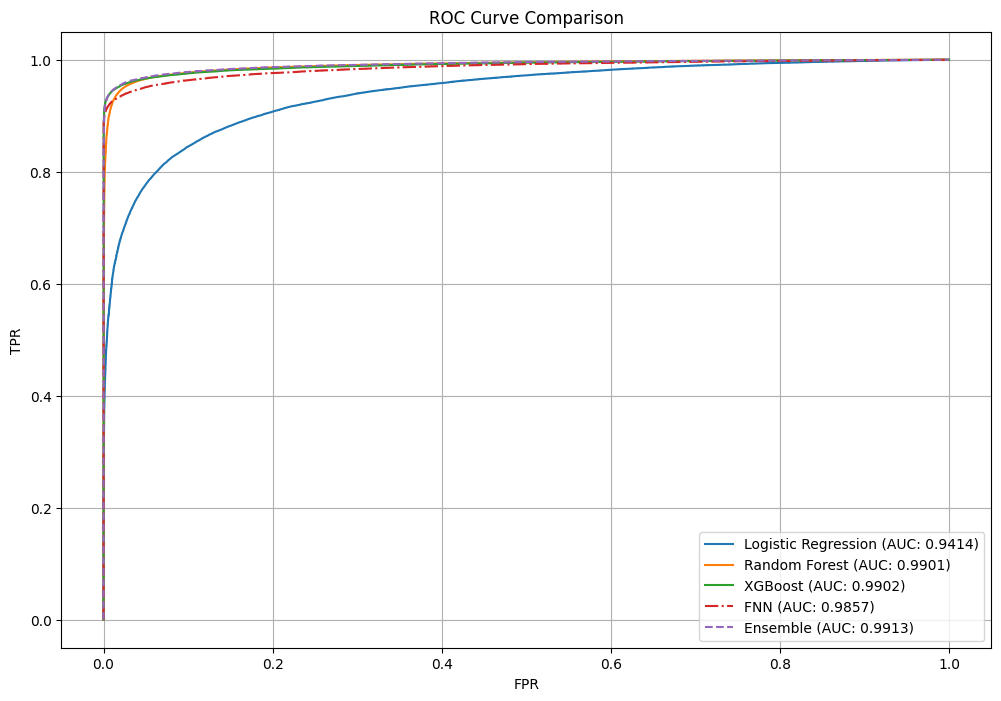

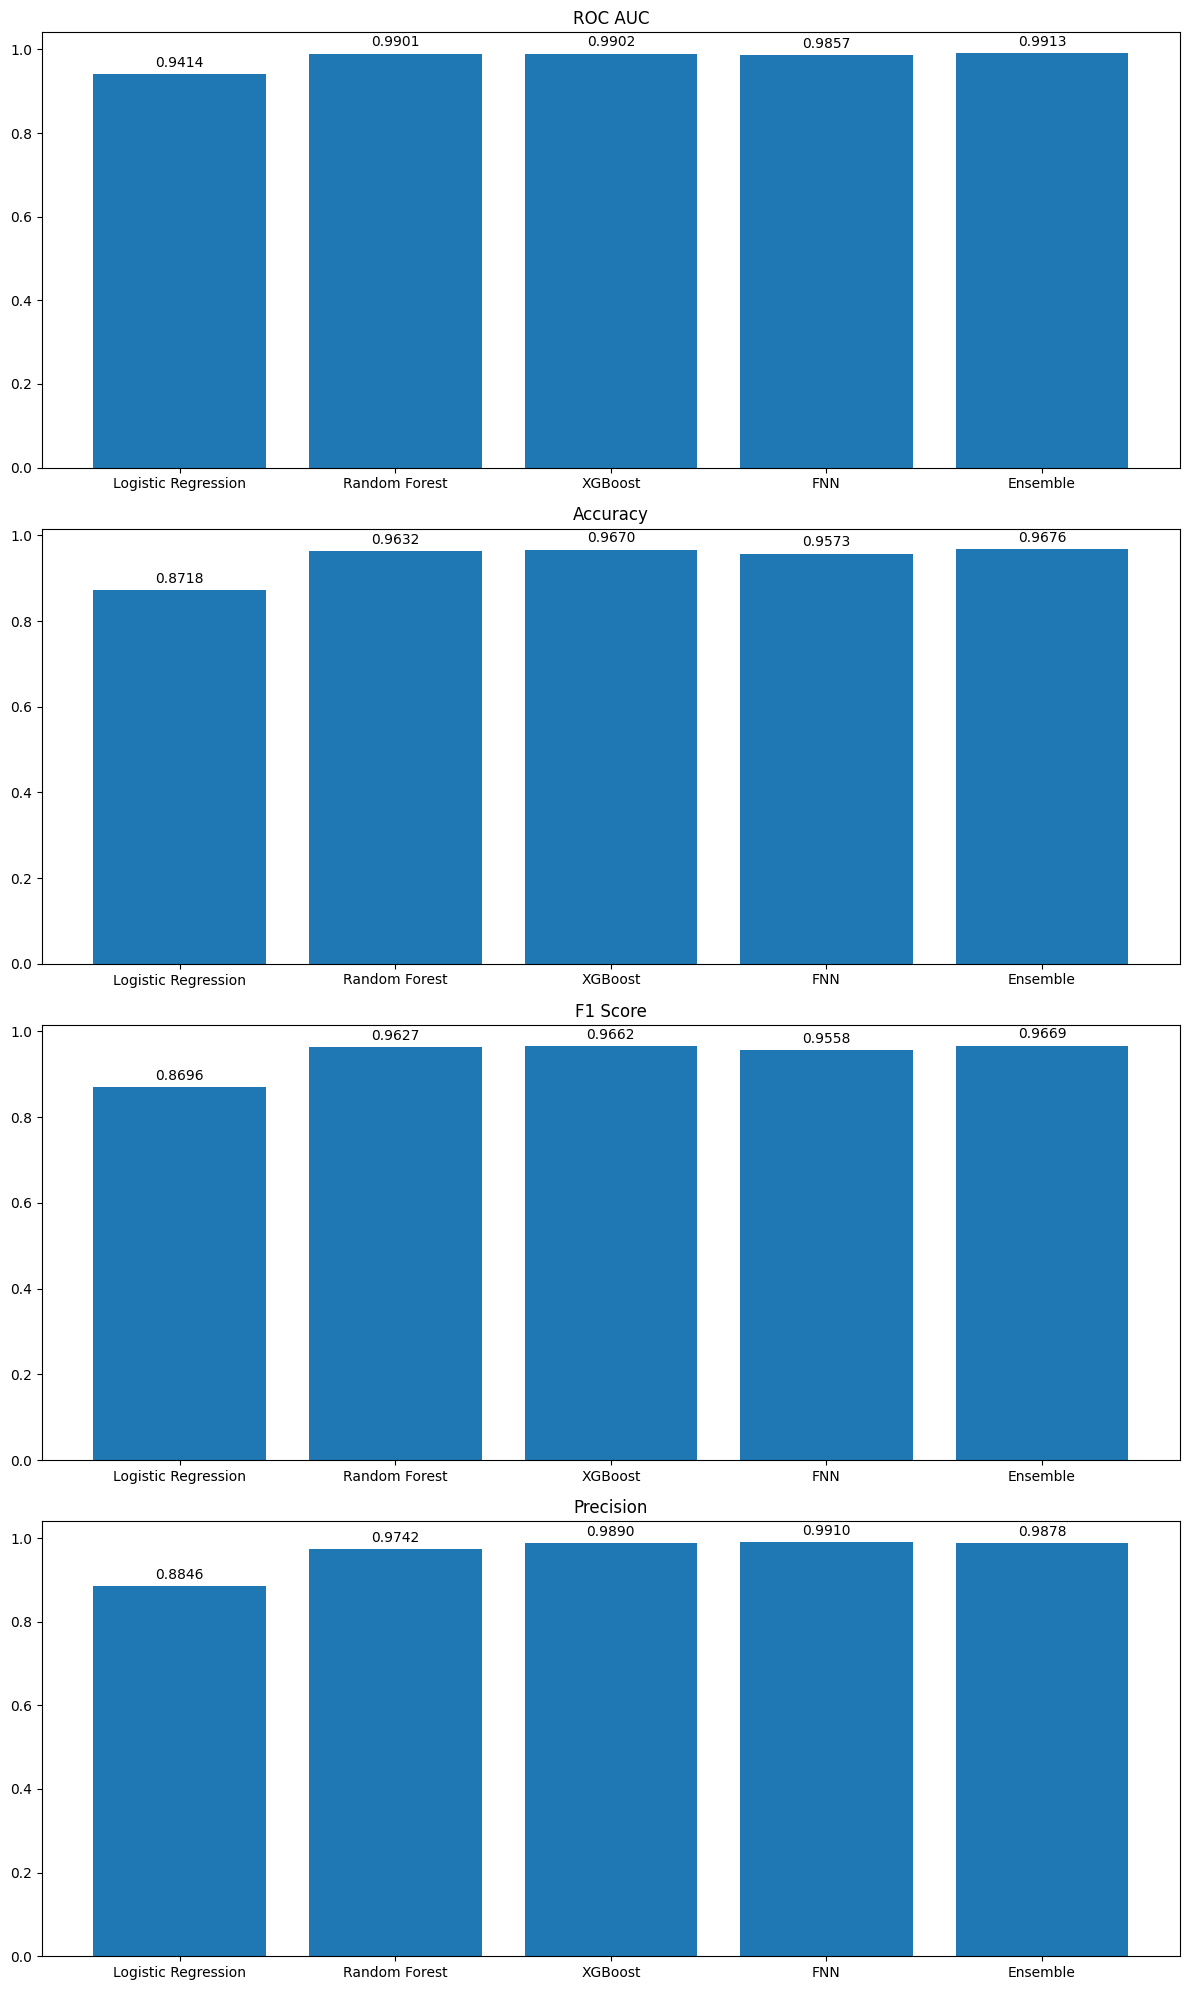

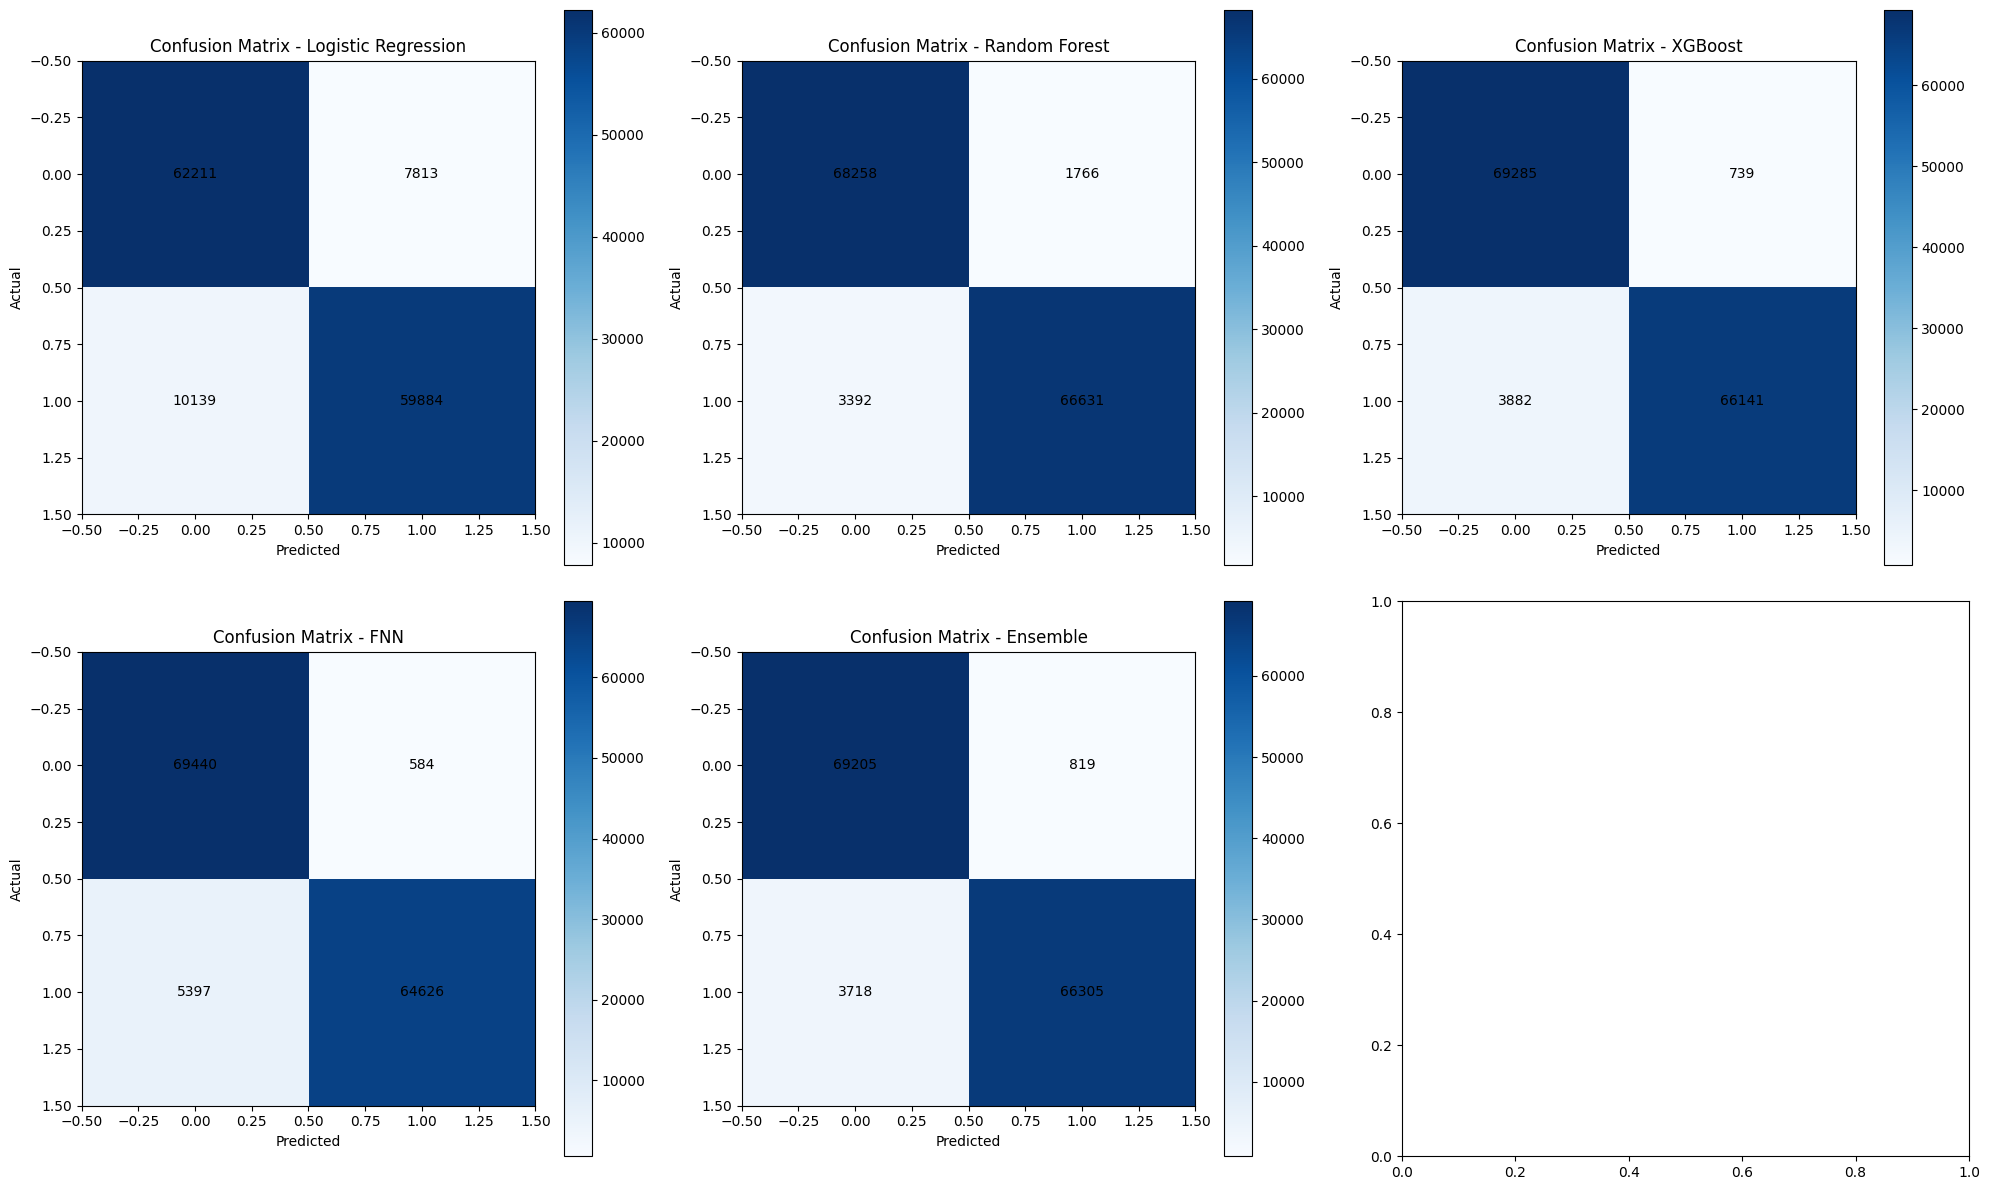

Data Distribution before applying the <class 'imblearn.over_sampling._adasyn.ADASYN'> method:
 Is Fraudulent
0    350116
1     18313
Name: count, dtype: int64

Data Distribution after applying the <class 'imblearn.over_sampling._adasyn.ADASYN'> method:
 Is Fraudulent
0    350116
1    349030
Name: count, dtype: int64
4370/4370 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
4370/4370 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
4370/4370 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
                 Model   ROC AUC  Accuracy  F1 Score  Precision    Recall  \
0  Logistic Regression  0.935178  0.862118  0.859969   0.872182  0.848093   
1        Random Forest  0.990298  0.963205  0.962742   0.973450  0.952268   
2              XGBoost  0.990456  0.965801  0.964932   0.988491  0.942469   
3                  FNN  0.986056  0.958299  0.956923   0.987934  0.927800   
4             Ensemble  0.991593  0.967246  0.966531   0.986485  0.947368   

                                              y_prob  \
0  [0.011152140820202577, 0.043082

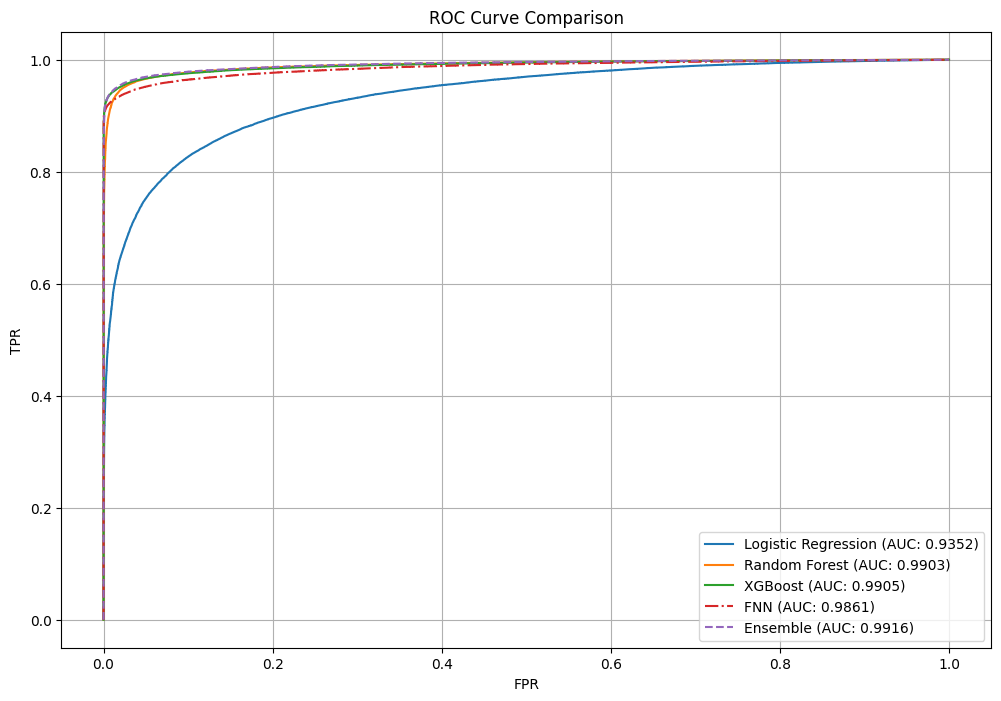

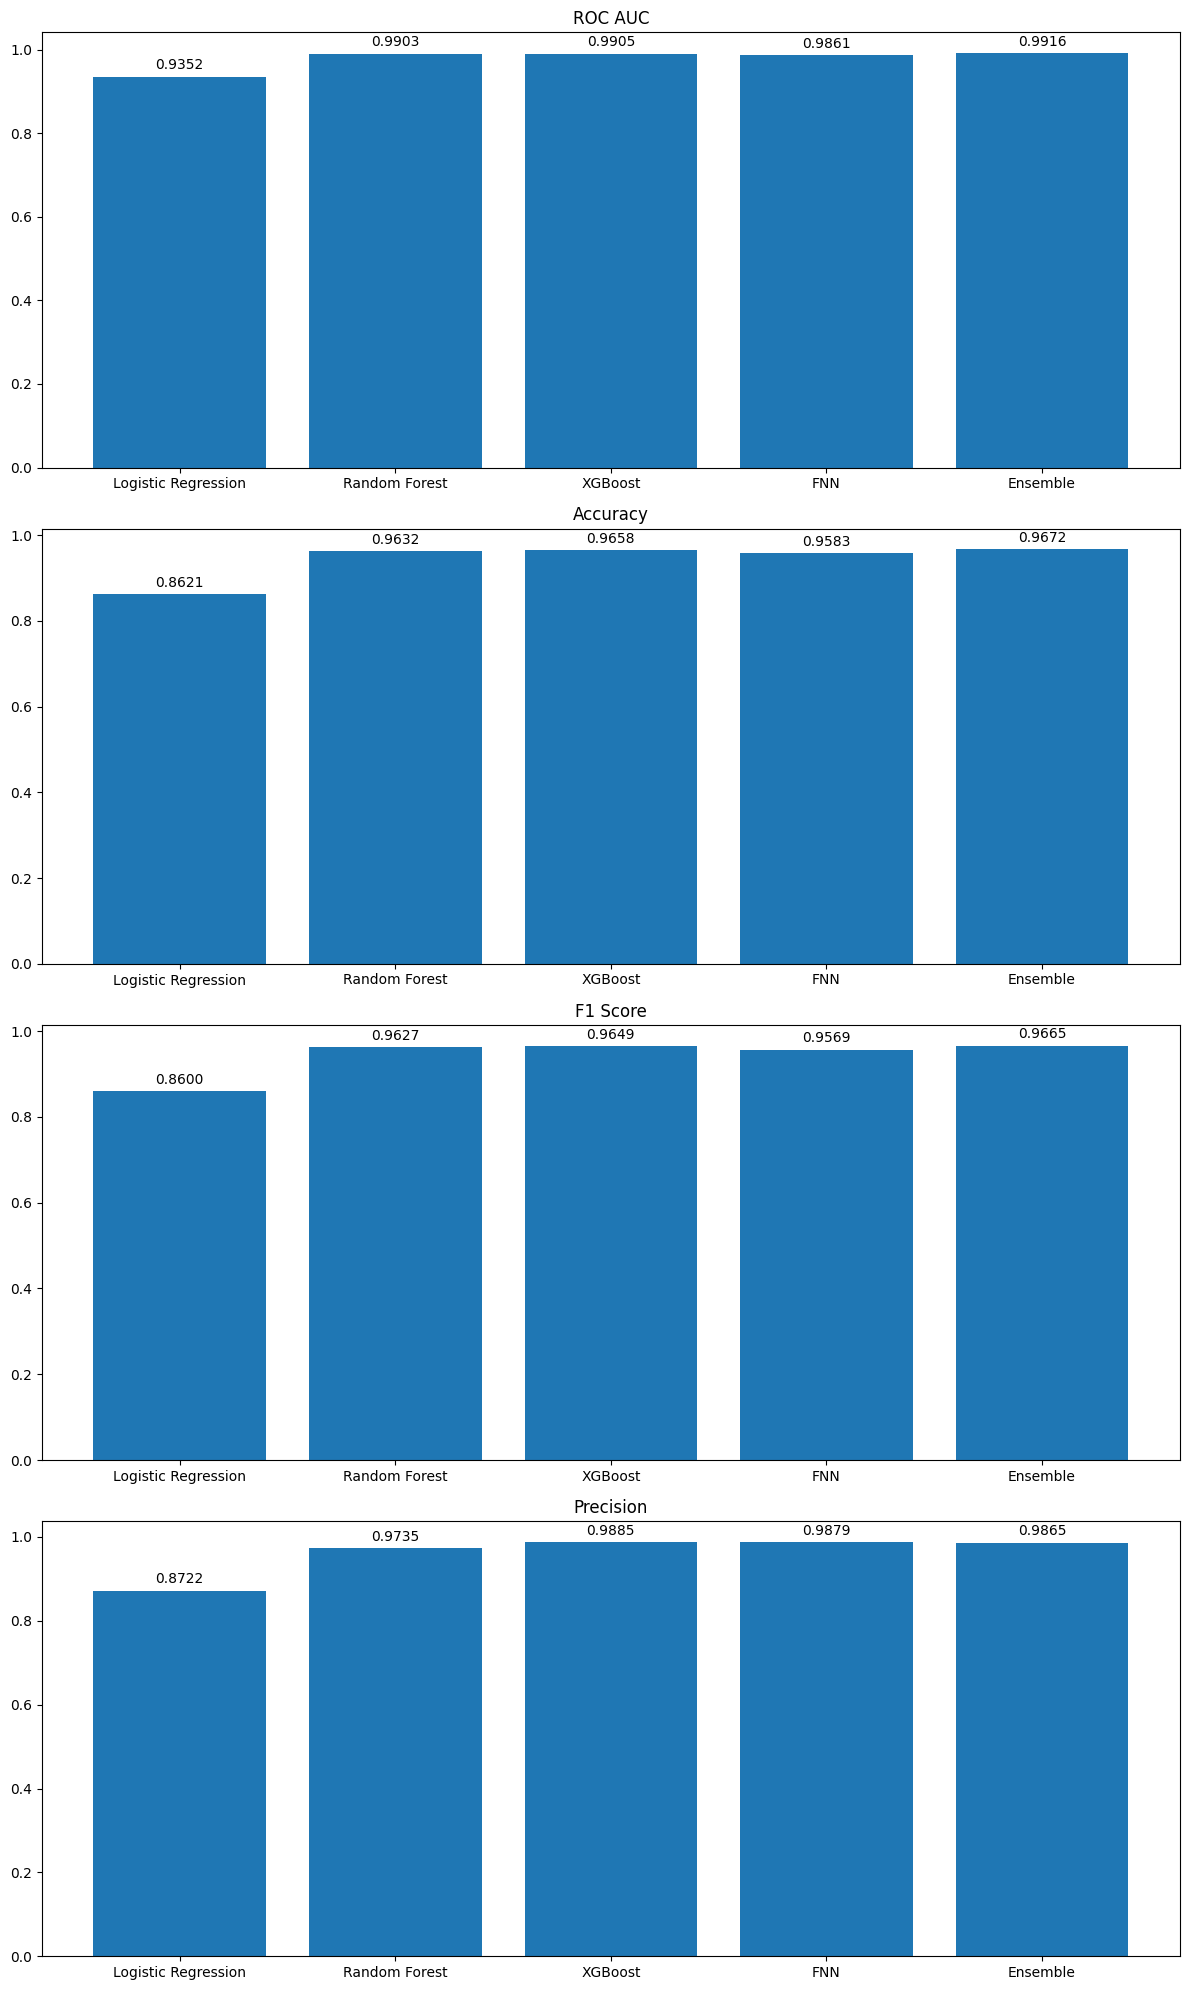

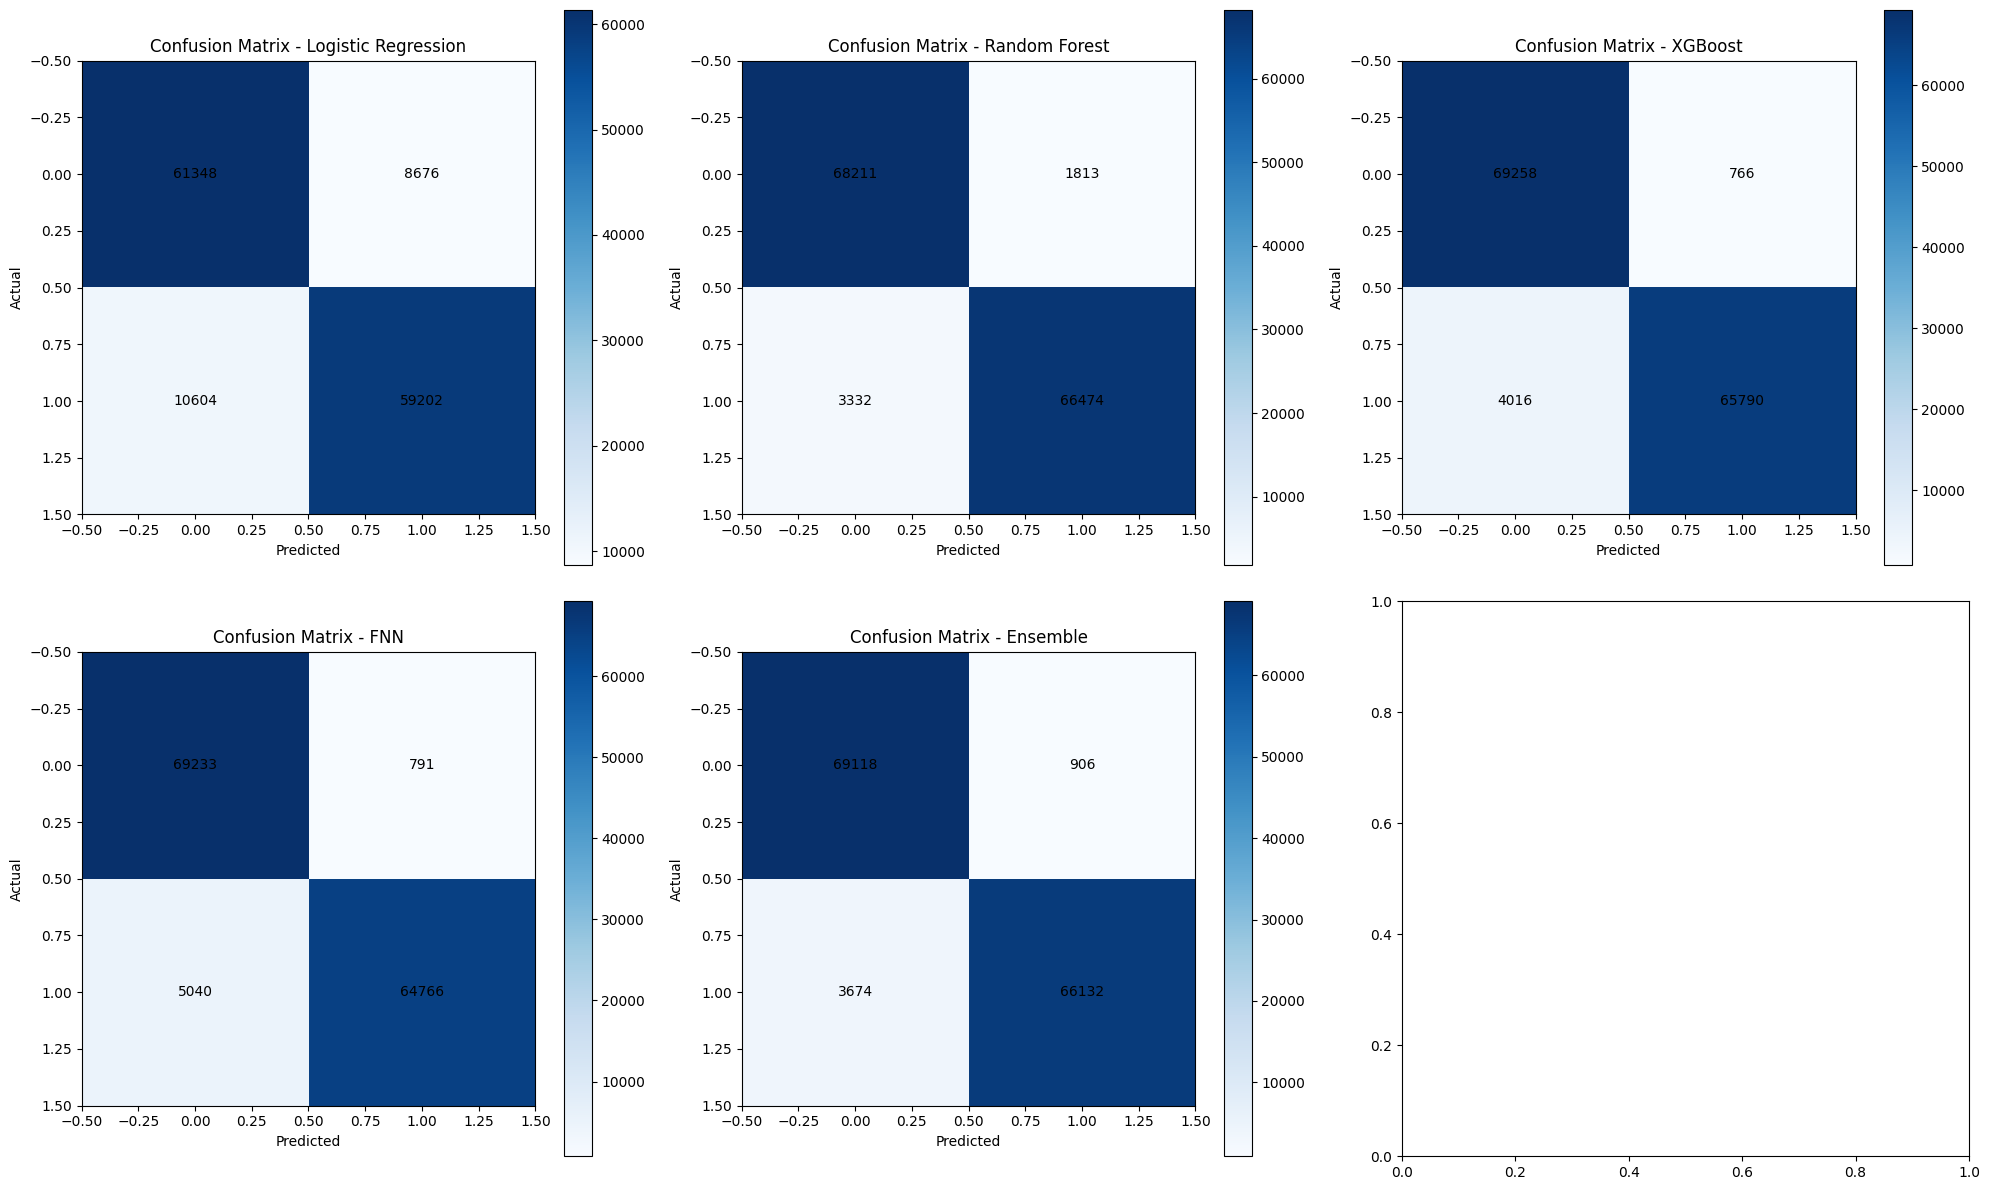

Data Distribution before applying the <class 'imblearn.over_sampling._smote.filter.SVMSMOTE'> method:
 Is Fraudulent
0    350116
1     18313
Name: count, dtype: int64

Data Distribution after applying the <class 'imblearn.over_sampling._smote.filter.SVMSMOTE'> method:
 Is Fraudulent
0    350116
1    350116
Name: count, dtype: int64
4377/4377 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
4377/4377 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
4377/4377 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
                 Model   ROC AUC  Accuracy  F1 Score  Precision    Recall  \
0  Logistic Regression  0.968411  0.916578  0.914804   0.934672  0.895763   
1        Random Forest  0.990377  0.967282  0.966962   0.976524  0.957585   
2              XGBoost  0.990319  0.969824  0.969237   0.988478  0.950730   
3                  FNN  0.988215  0.964034  0.963143   0.987590  0.939877   
4             Ensemble  0.990545  0.971460  0.970992   0.987162  0.955343   

                                              y_prob  \
0  [0.142133379329

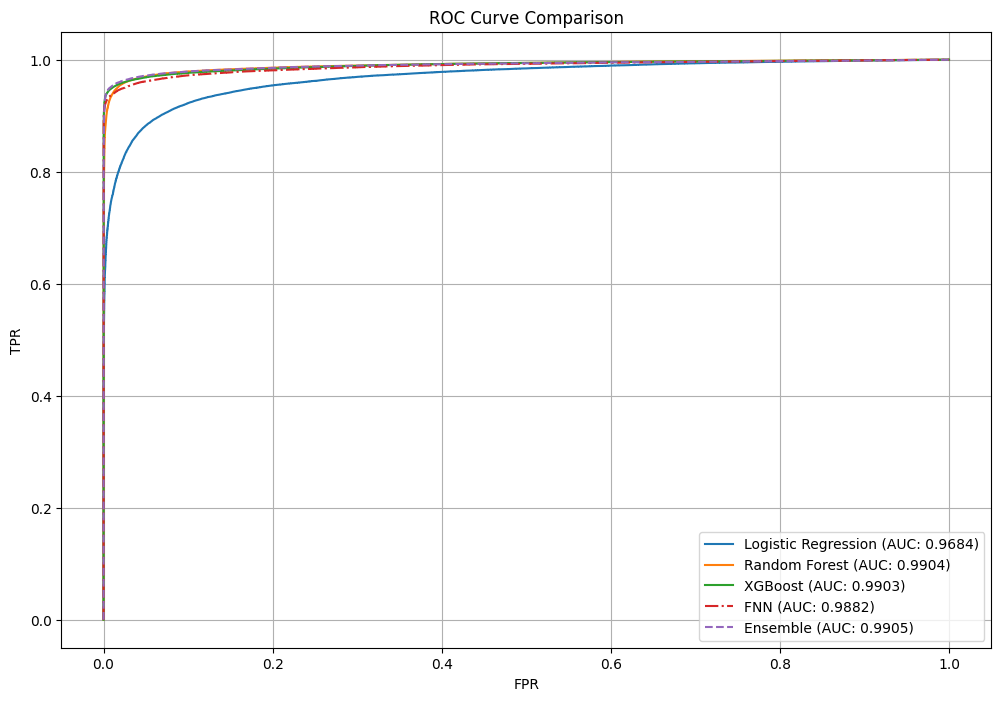

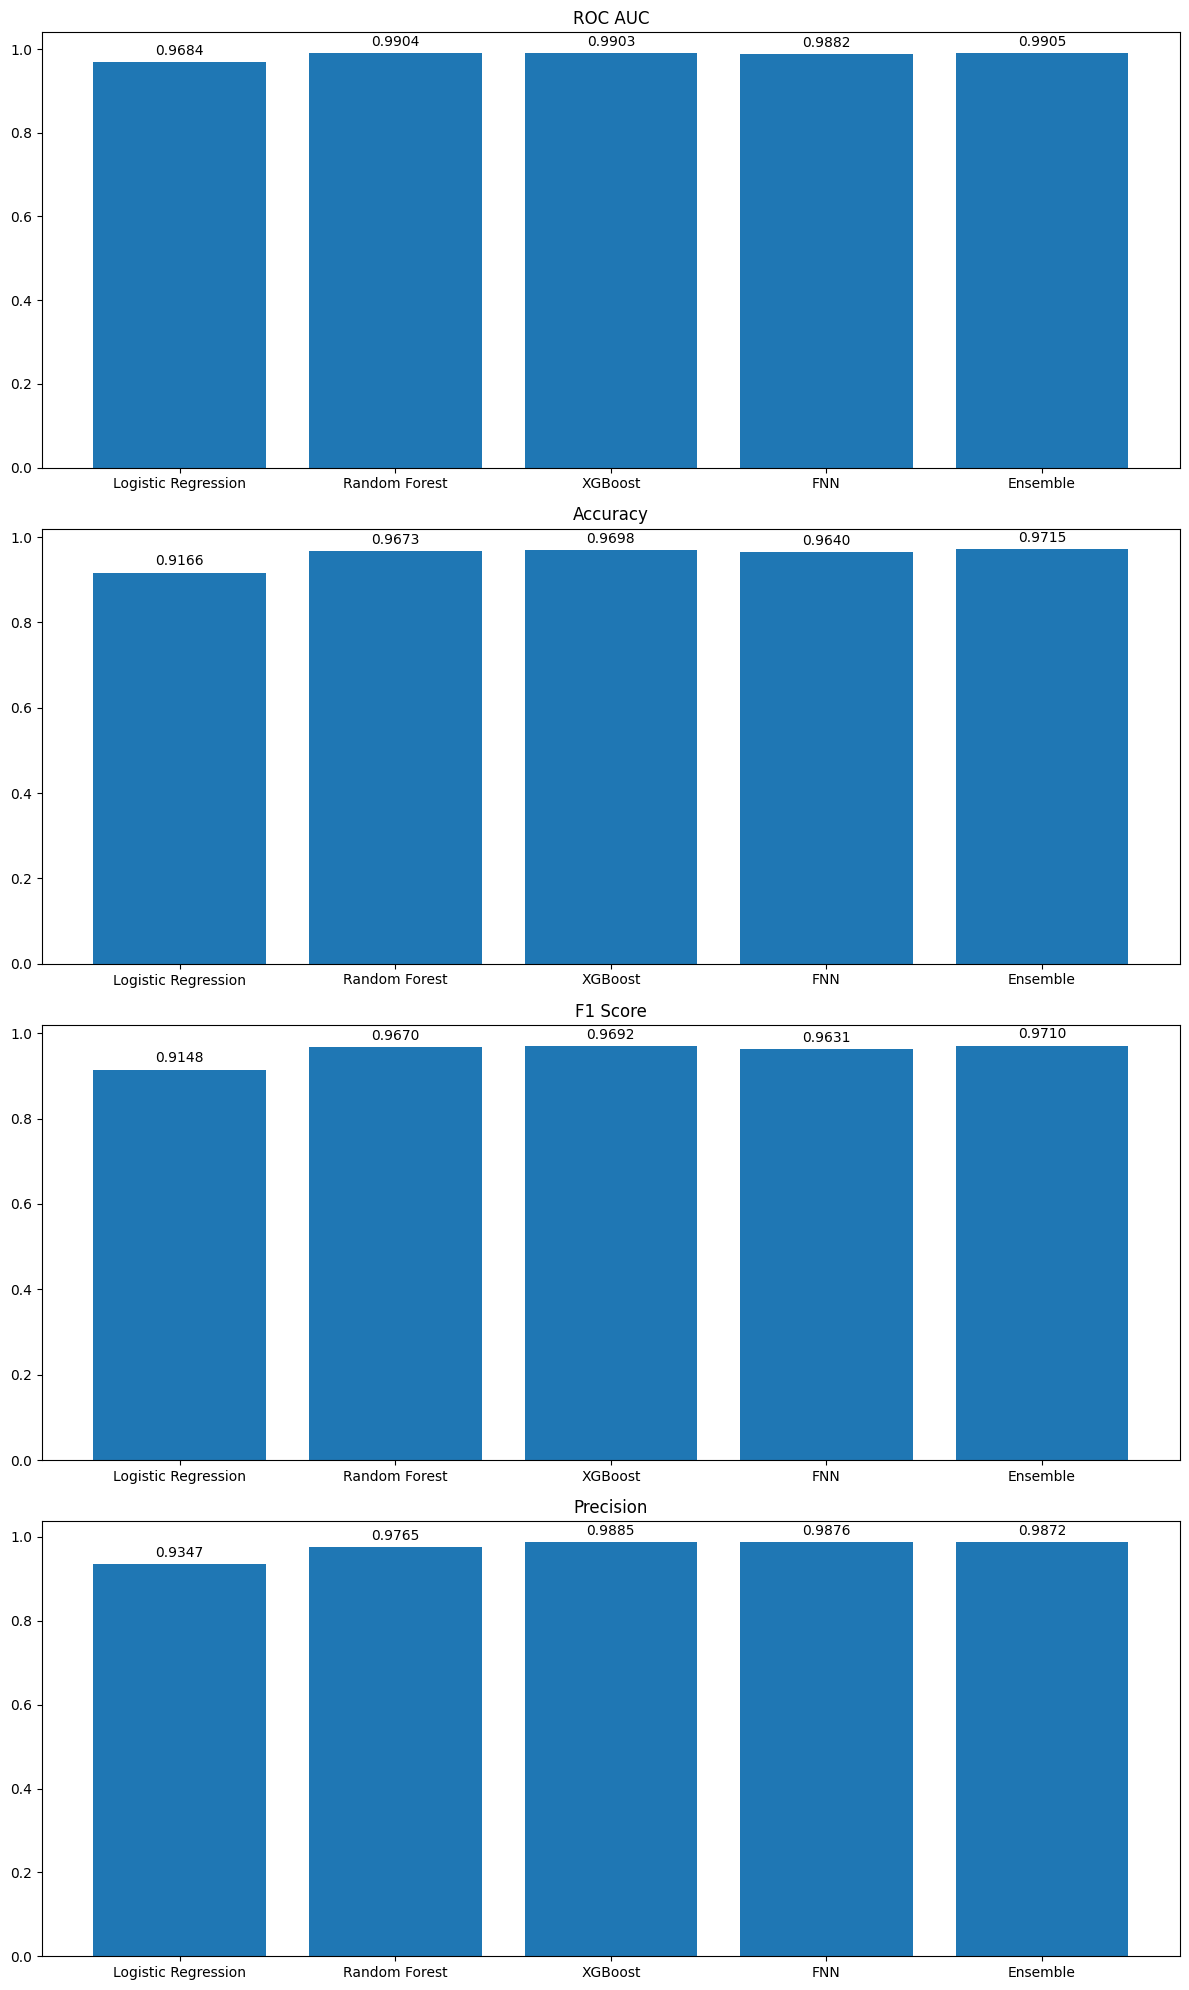

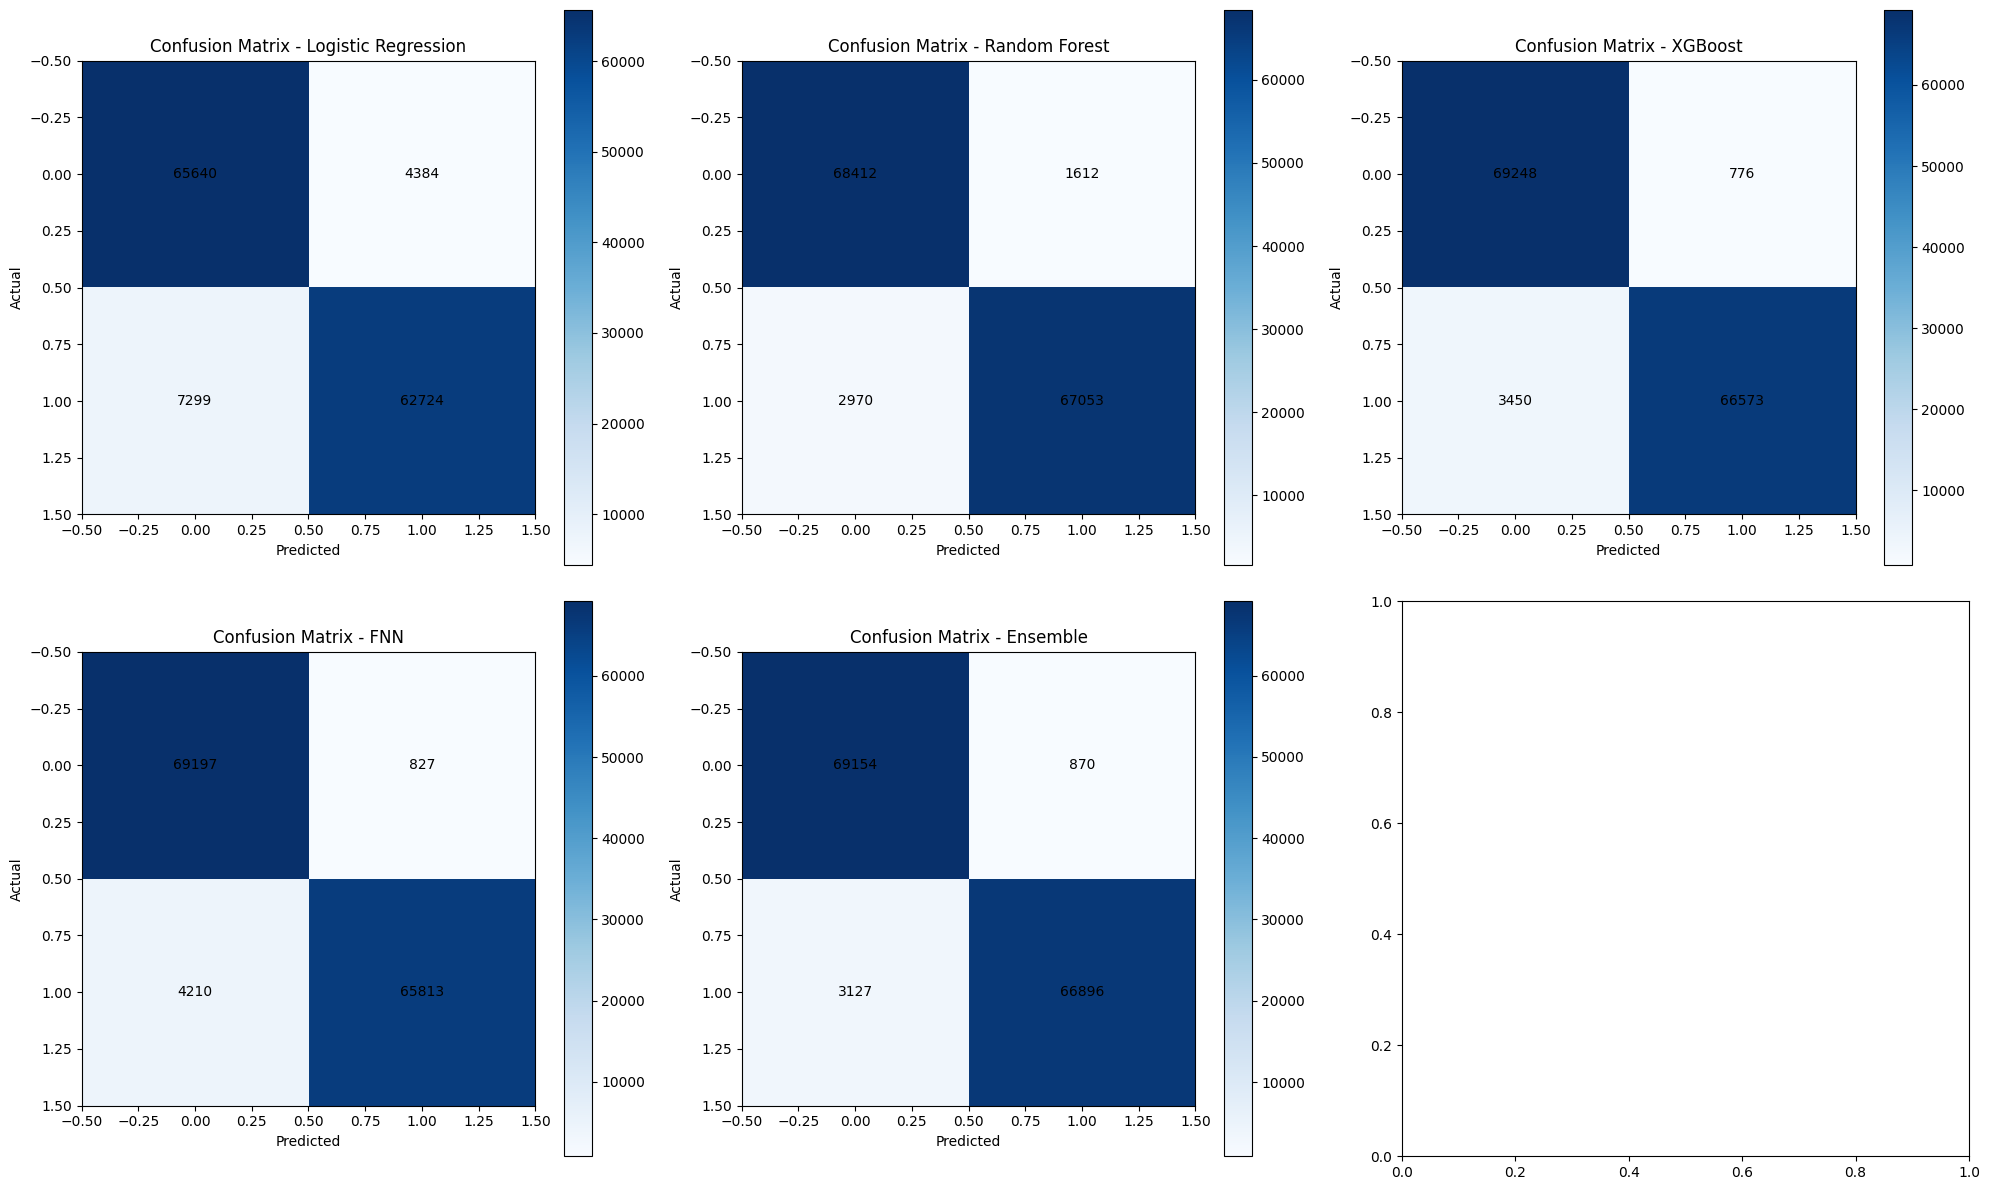

In [302]:
pipeline.trainAndEvaluate()